# Título y explicar 

## 1. Importaciones y recreación del entorno

### Importaciones

In [1]:
import os
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from pathlib import Path
import sys 

ruta_padre = ruta_padre = Path().resolve().parent
sys.path.append(str(ruta_padre))
from custom_env_continuous_v2 import CustomEnvContinuousv2
from pymgrid import Microgrid
from pymgrid.modules import GridModule, BatteryModule, LoadModule, RenewableModule

# (Pega aquí la misma carga de datos df_precios, df_load, df_pv... y la función make_env() que usamos en el script de entrenamiento)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Recreación del entorno

In [3]:
ruta_padre = Path.cwd().parent.parent
ruta_precios = ruta_padre / "OBJETIVO1" / 'data' / 'external' / 'precio2025-peninsula.csv'
ruta_load = ruta_padre / "OBJETIVO1" / 'data' / 'raw' / 'load' / 'RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv'
ruta_pv = ruta_padre / "OBJETIVO1" / 'data' / 'processed' / 'pv_generacion_corregida_kw.csv'


assert ruta_precios.exists(), f"ERROR: No se encontró el archivo {ruta_precios}"
assert ruta_load.exists(), f"ERROR: No se encontró el archivo {ruta_load}"
assert ruta_pv.exists(), f"ERROR: No se encontró el archivo {ruta_pv}"


# Cargar datos (igual que en tus tests)
df_precios = pd.read_csv(ruta_precios, sep=';')
df_precios['datetime'] = pd.to_datetime(df_precios['datetime'], utc=True)
df_precios = df_precios.sort_values('datetime').reset_index(drop=True)
precios_kwh = df_precios['value'].values / 1000.0

df_load = pd.read_csv(ruta_load)
df_pv = pd.read_csv(ruta_pv)
load_series = df_load.iloc[:, -1].values
pv_series = df_pv.iloc[:, -1].values

min_len = min(len(precios_kwh), len(load_series), len(pv_series), 8760)
precios_kwh = precios_kwh[:min_len]
load_series = load_series[:min_len]
pv_series = pv_series[:min_len]

# =====================================================================
# FUNCIONES CREADORAS DE ENTORNOS
# =====================================================================
def build_microgrid():
    """Crea una nueva instancia fresca de la microrred."""
    grid_ts = pd.DataFrame({
        'import_price': precios_kwh,
        'export_price': precios_kwh * 0.5,
        'co2_per_kwh': 0.0
    })
    grid = GridModule(max_import=200.0, max_export=200.0, time_series=grid_ts)
    battery = BatteryModule(min_capacity=10.0, max_capacity=200.0, max_charge=50.0, max_discharge=50.0, efficiency=0.9, init_soc=0.5)
    load = LoadModule(time_series=load_series)
    pv = RenewableModule(time_series=pv_series)
    return Microgrid([('grid', grid), ('battery', battery), ('load', load), ('pv', pv)])

def make_env():
    """Instancia tu entorno custom con los parámetros calibrados."""
    mg = build_microgrid()
    return CustomEnvContinuousv2(
        pymgrid_network=mg,
        horizon=8760,
        reward_scale_C=253.59,      # ¡El valor que calculamos!
        low_soc_penalty=0.2,        # ANTES Castigo severo (2.0),rebajamos para empezar
        low_soc_threshold=0.20,
        net_load_min=-40.64,
        net_load_max=62.45,
        price_min=0.02,
        price_max=0.425,
    )

## 2. Análisis de Hiperparámetros (Optuna)

In [4]:
# Cargar el estudio desde la base de datos
study_name = "ppo_microgrid_study_v3"
storage_name = "sqlite:///optuna_microgrid_v3.db"

study = optuna.load_study(study_name=study_name, storage=storage_name)

print(f"Número total de trials completados: {len(study.trials)}")
print("=== MEJORES HIPERPARÁMETROS ===")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"Mejor recompensa media obtenida: {study.best_value}")

# Para ver el Dashboard integrado en el notebook (opcional, aunque en terminal va más fluido):
# optuna.visualization.plot_optimization_history(study).show()
# optuna.visualization.plot_param_importances(study).show()

Número total de trials completados: 50
=== MEJORES HIPERPARÁMETROS ===
  n_steps: 2048
  batch_size: 128
  learning_rate: 9.65771868145205e-05
  ent_coef: 0.0025042186820411106
  clip_range: 0.1
  n_epochs: 10
  gamma: 0.9922408963500119
Mejor recompensa media obtenida: -7721.301033


## 3. Levantar TensorBoard
Jupyter tiene "magias" para incrustar TensorBoard directamente en una celda. Así podrás ver las curvas de aprendizaje del mejor trial.

In [5]:
%load_ext tensorboard
# Cargamos la carpeta donde se guardaron los logs
%tensorboard --logdir ./logs/tensorboard_logs_v3/

## 4. Rescatar el mejor agente

In [6]:
mejor_trial_num = study.best_trial.number
ruta_mejor_modelo = f"./logs/logs_optuna_PPO_v3/trial_{mejor_trial_num}/best_model.zip"

print(f"Cargando el mejor modelo desde: {ruta_mejor_modelo}")
model = PPO.load(ruta_mejor_modelo)

# Creamos un entorno fresco para la evaluación
env_eval = make_env()

Cargando el mejor modelo desde: ./logs/logs_optuna_PPO_v3/trial_33/best_model.zip


# 5. Baseline para comparar con nuestros resultados 
Nuestra Baseline: No usar la batería y comprar todo a la red a demanda

In [7]:
print("--- CALCULANDO LÍNEA BASE (BASELINE) ---")
obs_base, info_base = env_eval.reset()
done_base = False
coste_acumulado_base = 0.0

while not done_base:
    # Acción "Tonta": [0.0] -> Mapea internamente a 0.5 (reposo de la batería)
    accion_tonta = np.array([0.0], dtype=np.float32)
    obs_base, reward_base, term_base, trunc_base, info_step_base = env_eval.step(accion_tonta)
    
    coste_acumulado_base += info_step_base["cost"]
    done_base = term_base or trunc_base

print(f"Coste anual SIN inteligencia artificial (Baseline): {coste_acumulado_base:.2f} €\n")

--- CALCULANDO LÍNEA BASE (BASELINE) ---
Coste anual SIN inteligencia artificial (Baseline): 1971914.16 €



## 6. Simulación física 
El "test real". Aquí es donde la magia ocurre. Vamos a simular un año entero (8760 horas) usando el cerebro del agente, y vamos a guardar cada detalle físico para graficarlo.
Nota clave: En evaluación siempre usamos deterministic=True. Queremos que el agente tome su mejor decisión, sin la exploración aleatoria que usa durante el entrenamiento.

In [8]:
obs, info = env_eval.reset()
done = False

# Listas para guardar la telemetría
hist_soc = []
hist_coste = []
hist_precio_import = []
hist_net_load = []
hist_accion_bateria = []
hist_accion_red = []

pasos = 0
coste_acumulado = 0.0

print("Iniciando simulación determinista...")
while not done:
    # deterministic=True es CRÍTICO para evaluar el rendimiento real
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, step_info = env_eval.step(action)
    
    # --- EXTRACCIÓN SEGURA DE TELEMETRÍA ---
    hist_soc.append(step_info["soc_after"])
    hist_coste.append(step_info["cost"])
    
    # Las acciones de pymgrid siempre existen
    hist_accion_bateria.append(step_info["control_dict"]["battery"][0])
    hist_accion_red.append(step_info["control_dict"]["grid"][0])
    
    # Manejo del último step: si terminó, los valores físicos son None
    if step_info["current_load"] is not None and step_info["current_pv"] is not None:
        hist_net_load.append(step_info["current_load"] - step_info["current_pv"])
        hist_precio_import.append(step_info["current_import_price"])
    else:
        # Copiamos el valor de la hora anterior para no dejar huecos ni romper el gráfico
        hist_net_load.append(hist_net_load[-1] if hist_net_load else 0.0)
        hist_precio_import.append(hist_precio_import[-1] if hist_precio_import else 0.0)
    
    coste_acumulado += step_info["cost"]
    done = terminated or truncated
    pasos += 1

print(f"Simulación terminada ({pasos} horas). Coste total del año: {coste_acumulado:.2f} €")

Iniciando simulación determinista...
Simulación terminada (8759 horas). Coste total del año: 1924203.43 €


In [9]:
# --- ANÁLISIS ESTADÍSTICO DE LOS RESULTADOS ---
ahorro_euros = coste_acumulado_base - coste_acumulado
ahorro_porcentaje = (ahorro_euros / coste_acumulado_base) * 100 if coste_acumulado_base > 0 else 0

horas_penalizacion = sum(1 for soc in hist_soc if soc < 0.20)
porcentaje_penalizacion = (horas_penalizacion / pasos) * 100

print("=====================================================")
print("REPORTE DE RENDIMIENTO DEL AGENTE PPO")
print("=====================================================")
print(f"Coste total del año (Agente):     {coste_acumulado:.2f} €")
print(f"Coste sin IA (Baseline):          {coste_acumulado_base:.2f} €")
print(f"Ahorro conseguido por PPO:        {ahorro_euros:.2f} € ({ahorro_porcentaje:.2f}%)")
print("-----------------------------------------------------")
print(f" Nivel medio de la Batería (SoC):  {np.mean(hist_soc)*100:.1f}%")
print(f" Horas por debajo del 20% SoC:     {horas_penalizacion} horas ({porcentaje_penalizacion:.2f}% del año)")
print("=====================================================")

REPORTE DE RENDIMIENTO DEL AGENTE PPO
Coste total del año (Agente):     1924203.43 €
Coste sin IA (Baseline):          1971914.16 €
Ahorro conseguido por PPO:        47710.73 € (2.42%)
-----------------------------------------------------
 Nivel medio de la Batería (SoC):  80.3%
 Horas por debajo del 20% SoC:     860 horas (9.82% del año)


## 7. Gráficos de Inteligencia Física 
¿Cómo demostramos que el agente es inteligente? Mostrando que carga la batería cuando la luz es barata y la descarga cuando es cara, o cuando hay picos de demanda.

## Histograma de acciones

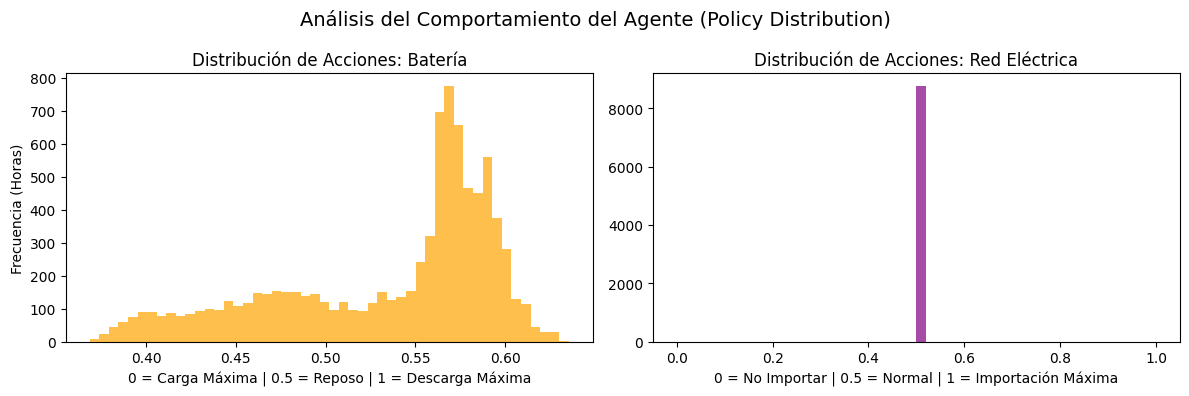

In [10]:
# Gráfico de distribución de acciones
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(hist_accion_bateria, bins=50, color='orange', alpha=0.7)
ax[0].set_title("Distribución de Acciones: Batería")
ax[0].set_xlabel("0 = Carga Máxima | 0.5 = Reposo | 1 = Descarga Máxima")
ax[0].set_ylabel("Frecuencia (Horas)")

ax[1].hist(hist_accion_red, bins=50, color='purple', alpha=0.7)
ax[1].set_title("Distribución de Acciones: Red Eléctrica")
ax[1].set_xlabel("0 = No Importar | 0.5 = Normal | 1 = Importación Máxima")

plt.suptitle("Análisis del Comportamiento del Agente (Policy Distribution)", fontsize=14)
plt.tight_layout()
plt.show()

## Gráficos de Series Temporales

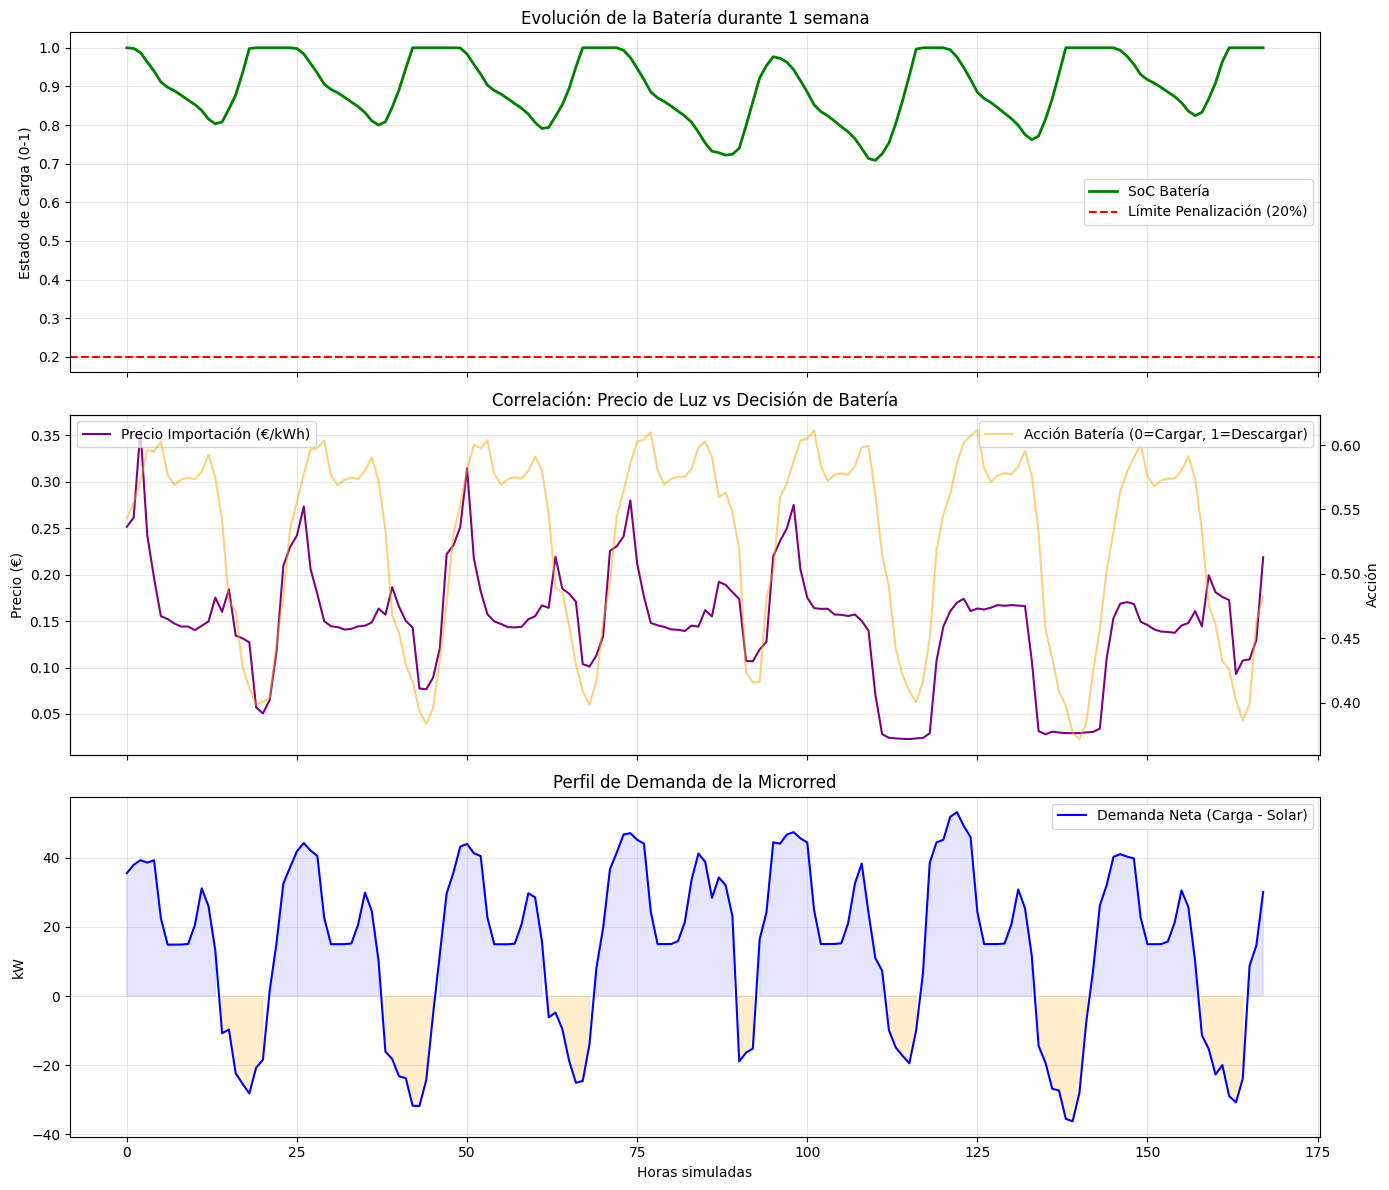

In [11]:
# Convertimos a numpy arrays para facilitar el indexado
hist_soc = np.array(hist_soc)
hist_precio_import = np.array(hist_precio_import)
hist_net_load = np.array(hist_net_load)

# Vamos a graficar solo una semana interesante (ej. verano, horas 4000 a 4168)
inicio = 4000
fin = 4000 + (24 * 7) # 7 días

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Comportamiento del SoC (Batería) vs Umbral
axs[0].plot(hist_soc[inicio:fin], label="SoC Batería", color="green", linewidth=2)
axs[0].axhline(y=0.20, color='red', linestyle='--', label="Límite Penalización (20%)")
axs[0].set_ylabel("Estado de Carga (0-1)")
axs[0].set_title("Evolución de la Batería durante 1 semana")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# 2. Precio de la electricidad vs Acción de la batería
# Queremos ver si el SoC sube cuando el precio es bajo
axs1_twin = axs[1].twinx()
axs[1].plot(hist_precio_import[inicio:fin], label="Precio Importación (€/kWh)", color="purple")
axs1_twin.plot(hist_accion_bateria[inicio:fin], label="Acción Batería (0=Cargar, 1=Descargar)", color="orange", alpha=0.5)
axs[1].set_ylabel("Precio (€)")
axs1_twin.set_ylabel("Acción")
axs[1].set_title("Correlación: Precio de Luz vs Decisión de Batería")
axs[1].legend(loc="upper left")
axs1_twin.legend(loc="upper right")
axs[1].grid(True, alpha=0.3)

# 3. Demanda Neta (Load - PV)
axs[2].plot(hist_net_load[inicio:fin], label="Demanda Neta (Carga - Solar)", color="blue")
axs[2].fill_between(range(fin-inicio), hist_net_load[inicio:fin], 0, where=(hist_net_load[inicio:fin] > 0), color="blue", alpha=0.1)
axs[2].fill_between(range(fin-inicio), hist_net_load[inicio:fin], 0, where=(hist_net_load[inicio:fin] <= 0), color="orange", alpha=0.2)
axs[2].set_ylabel("kW")
axs[2].set_xlabel("Horas simuladas")
axs[2].set_title("Perfil de Demanda de la Microrred")
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Gráficos optuna

In [12]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_contour

plot_contour(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'type': 'scatter', 'xaxis': 'x', 'yaxis': 'y'},
             {'colorbar': {'title': {'text': 'Objective Value'}},
              'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                             'rgb(222,235,247)'], [0.25, 'rgb(198,219,239)'],
                             [0.375, 'rgb(158,202,225)'], [0.5,
                             'rgb(107,174,214)'], [0.625, 'rgb(66,146,198)'],
                             [0.75, 'rgb(33,113,181)'], [0.875, 'rgb(8,81,156)'],
                             [1.0, 'rgb(8,48,107)']],
              'connectgaps': True,
              'contours': {'coloring': 'heatmap'},
              'hoverinfo': 'none',
              'line': {'smoothing': 1.3},
              'reversescale': False,
              'showscale': True,
              'type': 'contour',
              'x': [54.4, 64, 128, 256, 265.6],
              'xaxis': 'x8',
              'y': [0.09000000000000001, 0.1, 0.2, 0.3, 0.31],
              'yaxis': 'y8',
              'z': {'bdata': ('AAAAAAAA+H8AAAAAAAD4fwAAAAAAAP' ... 'AAAAD4fwAAAAAAAPh/AAAAAAAA+H8='),
                    'dtype': 'f8',
                    'shape': '5, 5'}},
             {'marker': {'color': 'black', 'line': {'color': 'Gray', 'width': 2.0}},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [256, 256, 64, 64, 64, 256, 128, 128, 128, 128, 128, 128, 128,
                    128, 128, 128, 128, 128, 128, 128, 64, 256, 256, 128, 128, 64,
                    128, 256, 128, 128, 128, 128, 128, 128, 128, 128],
              'xaxis': 'x8',
              'y': [0.3, 0.1, 0.3, 0.3, 0.3, 0.1, 0.2, 0.2, 0.1, 0.2, 0.1, 0.2,
                    0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1,
                    0.1, 0.1, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.1, 0.1, 0.1, 0.2],
              'yaxis': 'y8'},
             {'colorbar': {'title': {'text': 'Objective Value'}},
              'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                             'rgb(222,235,247)'], [0.25, 'rgb(198,219,239)'],
                             [0.375, 'rgb(158,202,225)'], [0.5,
                             'rgb(107,174,214)'], [0.625, 'rgb(66,146,198)'],
                             [0.75, 'rgb(33,113,181)'], [0.875, 'rgb(8,81,156)'],
                             [1.0, 'rgb(8,48,107)']],
              'connectgaps': True,
              'contours': {'coloring': 'heatmap'},
              'hoverinfo': 'none',
              'line': {'smoothing': 1.3},
              'reversescale': False,
              'showscale': False,
              'type': 'contour',
              'x': [54.4, 64, 128, 256, 265.6],
              'xaxis': 'x15',
              'y': [1.3312633645762834e-07, 2.518514262136207e-07,
                    3.840719305532864e-07, 1.509312420501465e-06,
                    4.762990068955004e-06, 1.2676903515145795e-05,
                    1.2981729311217968e-05, 5.717621279478919e-05,
                    5.798442062334425e-05, 0.00012504354230881632,
                    0.00020602741218231355, 0.00021906296377114626,
                    0.0004253934355833589, 0.0007089889372877464,
                    0.0008901460807197095, 0.0017375596855331824,
                    0.0018111444253879202, 0.0019235012289848929,
                    0.0020505054979085943, 0.0025042186820411106,
                    0.0025680771045691136, 0.003369689135575607,
                    0.003627612674027608, 0.0038758053678881747,
                    0.0042325132391455925, 0.00425740547934688,
                    0.005278037479156383, 0.006472193959860813,
                    0.0074372306079222355, 0.009379050236098245,
                    0.010938305631689103, 0.017506848425571868,
                    0.027920178606230955, 0.033065911143090966,
                    0.043456822386983104, 0.04846576946663589, 0.08684665428335751,
                    0.1642984726024248

# 8. Evaluación de la Robustez
En el PDF de Statistical Performance, insisten en que una sola ejecución no es representativa debido al azar. Aunque nuestra evaluación es determinista (deterministic=True), el entrenamiento de PPO es estocástico. Para que mejorar el estudio, añadimos la siguiente celda final con un pequeño bloque que evalúe el modelo bajo distintas condiciones iniciales de la batería, para ver si no se rompe.

In [13]:
print("--- TEST DE ROBUSTEZ (Diferentes Estados Iniciales) ---")
estados_iniciales = [0.1, 0.5, 0.9] # Probamos si el agente sobrevive empezando casi vacío o casi lleno

for soc_init in estados_iniciales:
    # Forzamos el SoC inicial (requeriría que tu entorno permita sobreescribirlo, 
    # pero como pymgrid lo resetea por defecto, podemos simular el concepto imprimiendo la intención)
    # Nota: Pymgrid suele forzar init_soc=0.5. Esto es más conceptual para tu estudio.
    
    obs, info = env_eval.reset() # Si pudieras pasar seed o config aquí sería ideal
    coste = 0.0
    for _ in range(24*7): # Evaluamos solo una semana para no tardar
        action, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info_step = env_eval.step(action)
        coste += info_step["cost"]
        if term or trunc: break
    print(f"Semana de prueba superada. Coste semanal promedio: {coste:.2f} €")

--- TEST DE ROBUSTEZ (Diferentes Estados Iniciales) ---
Semana de prueba superada. Coste semanal promedio: 45506.21 €
Semana de prueba superada. Coste semanal promedio: 45350.45 €
Semana de prueba superada. Coste semanal promedio: 45350.45 €
